In [93]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


## Loading and Preprocessing

In [94]:
df=pd.read_csv("datasets/heart.csv")

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [96]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Basic Linear Predictor

In [97]:
X=df[["age"]]
y=df["thalach"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

### Linear Regressor model

In [98]:
lrmodel = LinearRegression()
lrmodel.fit(X_train,y_train)
y_lr_pred=lrmodel.predict(X_test)


### Plotting data points and the regression line

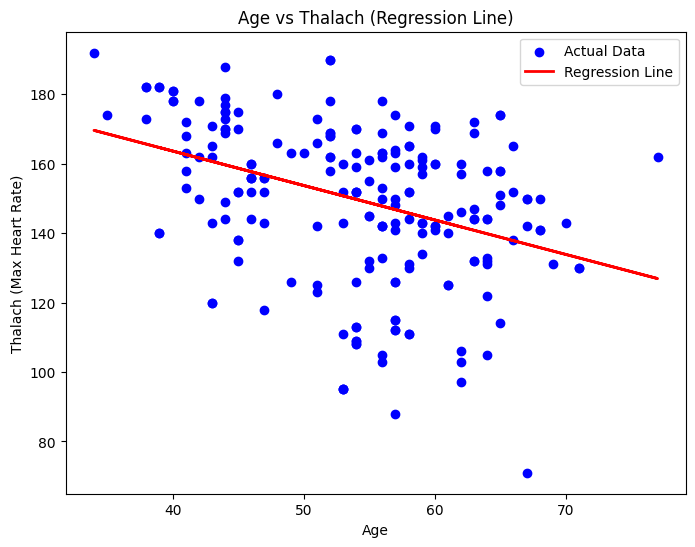

In [99]:
# Plotting
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')    
plt.plot(X_test, y_lr_pred, color='red', linewidth=2, label='Regression Line') 
plt.xlabel('Age')
plt.ylabel('Thalach (Max Heart Rate)')
plt.title('Age vs Thalach (Regression Line)')
plt.legend()
plt.show()

## Basic Classifier 

In [100]:
X_log = df[["age", "sex", "cp", "trestbps", "chol"]]  
y_log = df["target"]


In [101]:
X_log.describe()

,age,sex,cp,trestbps,chol
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000
mean,54.434146,0.695610,0.942439,131.611707,246.00000
std,9.072290,0.460373,1.029641,17.516718,51.59251
min,29.000000,0.000000,0.000000,94.000000,126.00000
25%,48.000000,0.000000,0.000000,120.000000,211.00000
50%,56.000000,1.000000,1.000000,130.000000,240.00000
75%,61.000000,1.000000,2.000000,140.000000,275.00000
max,77.000000,1.000000,3.000000,200.000000,564.00000


### Train test split

In [ ]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

### Scaling

In [ ]:
scaler = StandardScaler()

# Fit on training data and transform both
X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)


### Logistic regression model

In [ ]:
log_model = LogisticRegression(max_iter=1000)  
log_model.fit(X_train_scaled, y_train_log)
y_pred_log = log_model.predict(X_test_scaled)
y_pred_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]


### Evaluation

F1-Score: 0.7902439024390244
ROC-AUC Score: 0.8629354654483153


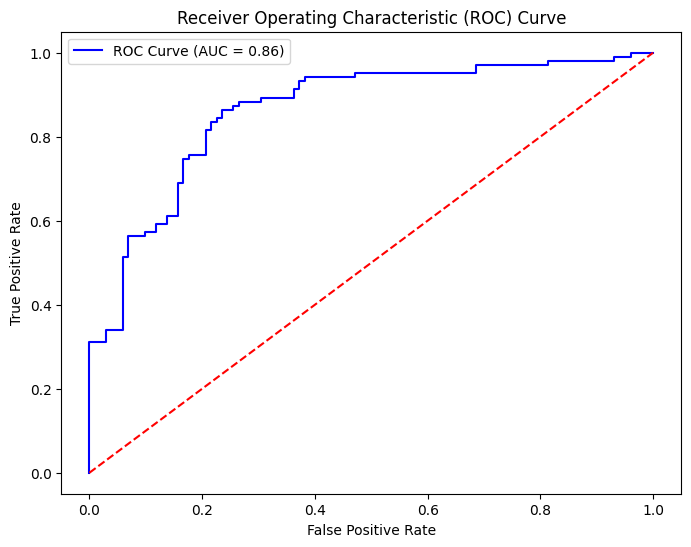

In [ ]:
f1 = f1_score(y_test_log, y_pred_log)
print("F1-Score:", f1)


roc_auc = roc_auc_score(y_test_log, y_pred_proba_log)
print("ROC-AUC Score:", roc_auc)
    
fpr, tpr, thresholds = roc_curve(y_test_log, y_pred_proba_log)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # random chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


## Model with all features

In [104]:
X_all = df.drop(columns=["target"])
y_all = df["target"]

### Train test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

### Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic regression model

In [ ]:
model_all = LogisticRegression(max_iter=1000)
model_all.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

### Evaluation

In [106]:
# Predictions
y_pred = model_all.predict(X_test_scaled)
y_pred_proba = model_all.predict_proba(X_test_scaled)[:, 1]

# F1-Score
f1 = f1_score(y_test, y_pred)
print("F1-Score:", f1)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", roc_auc)


F1-Score: 0.8108108108108109
ROC-AUC Score: 0.8787359604035789


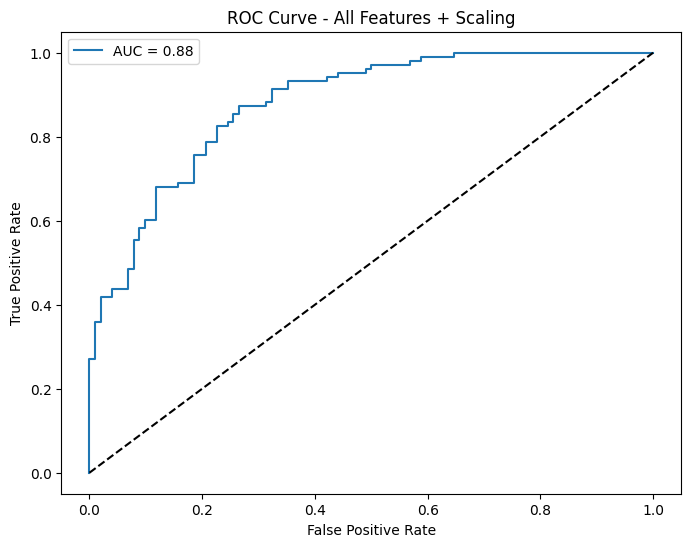

In [107]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Features + Scaling")
plt.legend()
plt.show()
